# Solubility Prediction — Example Notebook

This notebook demonstrates the **SolubilityPredict** package by running predictions on the Lovric dataset (non-overlapping subset with AqSolDB) and evaluating against measured values.

**Dataset**: `data/Lovric2020_logS0_nonoverlap.csv` — 275 molecules not present in the training set  
**Model**: Pre-trained Random Forest (`data/model.pkl`), trained on AqSolDB 80/20 split

## 1. Setup

In [1]:
import sys
import os

# Add the SolubilityPredict package root to path
pkg_root = os.path.abspath(".")
if pkg_root not in sys.path:
    sys.path.insert(0, pkg_root)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

from src.predict import predict, load_model

sns.set_theme(style="whitegrid", font_scale=1.1)

# Absolute path to the pre-trained model
MODEL_PATH = os.path.join(pkg_root, "data", "model.pkl")
print("Setup complete.")

Setup complete.


## 2. Load the Lovric dataset

In [2]:
df = pd.read_csv(os.path.join(pkg_root, "data", "Lovric2020_logS0_nonoverlap.csv"))
df = df.rename(columns={"isomeric_smiles": "smiles", "logS0": "Solubility"})
print(f"Total molecules: {len(df)}")
df.head()

Total molecules: 275


,smiles,Solubility
0,C1O[C@H]1c1ccccc1,-1.600
1,C=CCS[S@@](=O)CC=C,-0.830
2,CC#C[C@]1(O)CC[C@H]2[C@@H]3CCC4=CC(=O)CCC4=C3[...,-5.825
3,CC(=O)C[C@H](c1ccccc1)c1c(O)c2ccccc2oc1=O,-4.761
4,CC(=O)N1CCN(CC1)c1ccc(OC[C@H]2CO[C@@](Cn3ccnc3...,-3.800


In [3]:
# Check for missing SMILES or solubility values
print(f"Missing SMILES:     {df['smiles'].isna().sum()}")
print(f"Missing Solubility: {df['Solubility'].isna().sum()}")

df = df.dropna(subset=["smiles", "Solubility"]).reset_index(drop=True)
print(f"Molecules after dropping nulls: {len(df)}")

Missing SMILES:     0
Missing Solubility: 0
Molecules after dropping nulls: 275


## 3. Run predictions

In [4]:
model = load_model(MODEL_PATH)

smiles_list = df["smiles"].tolist()
print(f"Predicting solubility for {len(smiles_list)} molecules...")

results = predict(smiles_list, model=model)
print("Done.")

Predicting solubility for 275 molecules...
Done.


In [5]:
# Build results dataframe
results_df = pd.DataFrame(results)

# Separate valid predictions from errors
errors_df = results_df[results_df["error"].notna()]
valid_df  = results_df[results_df["error"].isna()].copy()

print(f"Successful predictions: {len(valid_df)}")
print(f"Failed (invalid SMILES): {len(errors_df)}")

if len(errors_df) > 0:
    print("\nSample failed SMILES:")
    print(errors_df[["smiles", "error"]].head())

Successful predictions: 275
Failed (invalid SMILES): 0


In [6]:
# Merge predictions with measured values
valid_df = valid_df.merge(
    df[["smiles", "Solubility"]],
    on="smiles",
    how="left"
).rename(columns={"Solubility": "logS_measured", "logS": "logS_predicted"})

valid_df = valid_df.dropna(subset=["logS_measured"])
valid_df[["smiles", "logS_measured", "logS_predicted", "category"]].head(10)

,smiles,logS_measured,logS_predicted,category
0,C1O[C@H]1c1ccccc1,-1.6000,-1.850,soluble
1,C=CCS[S@@](=O)CC=C,-0.8300,-0.974,highly soluble
2,CC#C[C@]1(O)CC[C@H]2[C@@H]3CCC4=CC(=O)CCC4=C3[...,-5.8250,-4.400,moderately soluble
3,CC(=O)C[C@H](c1ccccc1)c1c(O)c2ccccc2oc1=O,-4.7610,-4.576,moderately soluble
4,CC(=O)N1CCN(CC1)c1ccc(OC[C@H]2CO[C@@](Cn3ccnc3...,-3.8000,-4.717,moderately soluble
5,CC(=O)NC[C@H]1CN(C(=O)O1)c1ccc(N2CCN(CC2)C(=O)...,-1.9700,-3.022,moderately soluble
6,CC(=O)NC[C@H]1CN(C(=O)O1)c1ccc(N2CCOCC2)c(F)c1,-2.0700,-3.128,moderately soluble
7,CC(=O)O[C@@H]1C2=C(C)[C@H](C[C@@](O)([C@@H](OC...,-6.6300,-5.741,poorly soluble
8,CC(=O)O[C@]1(C(C)=O)C(=C)C[C@H]2[C@@H]3C=C(C)C...,-5.5700,-5.097,poorly soluble
9,CC(C)(C)NC(=O)[C@H]1CC[C@H]2[C@@H]3CC=C4C=C(CC...,-8.7585,-7.348,poorly soluble


## 4. Evaluate model performance

In [7]:
y_true = valid_df["logS_measured"].values
y_pred = valid_df["logS_predicted"].values

rmse = mean_squared_error(y_true, y_pred) ** 0.5
mae  = mean_absolute_error(y_true, y_pred)
r2   = r2_score(y_true, y_pred)

print(f"RMSE : {rmse:.3f} logS units")
print(f"MAE  : {mae:.3f} logS units")
print(f"R²   : {r2:.3f}")

RMSE : 0.762 logS units
MAE  : 0.501 logS units
R²   : 0.846


## 5. Parity plot — Measured vs. Predicted

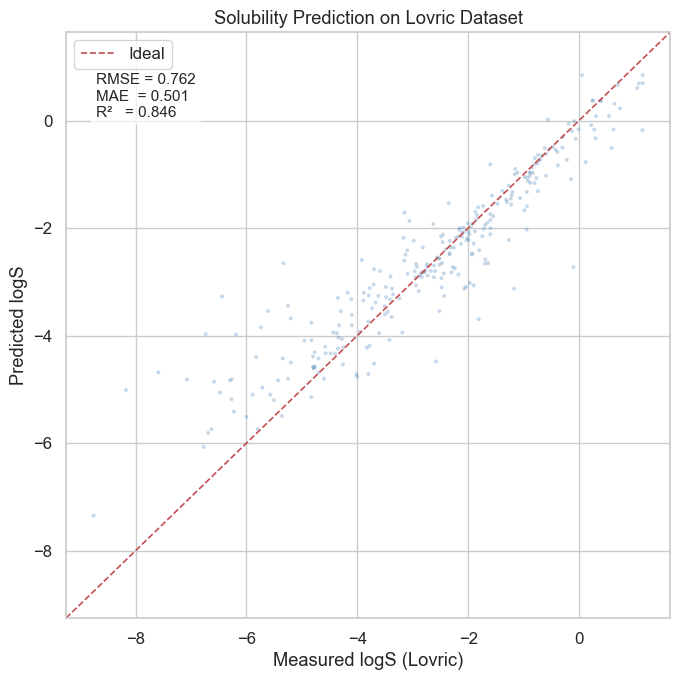

In [8]:
fig, ax = plt.subplots(figsize=(7, 7))

ax.scatter(y_true, y_pred, alpha=0.3, s=8, edgecolors="none", color="steelblue")

lim = [min(y_true.min(), y_pred.min()) - 0.5, max(y_true.max(), y_pred.max()) + 0.5]
ax.plot(lim, lim, "r--", linewidth=1.2, label="Ideal")
ax.set_xlim(lim)
ax.set_ylim(lim)

ax.set_xlabel("Measured logS (Lovric)")
ax.set_ylabel("Predicted logS")
ax.set_title("Solubility Prediction on Lovric Dataset")
ax.text(0.05, 0.93,
        f"RMSE = {rmse:.3f}\nMAE  = {mae:.3f}\nR²   = {r2:.3f}",
        transform=ax.transAxes, fontsize=11,
        verticalalignment="top",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.7))
ax.legend()
plt.tight_layout()
plt.show()

## 6. Error distribution

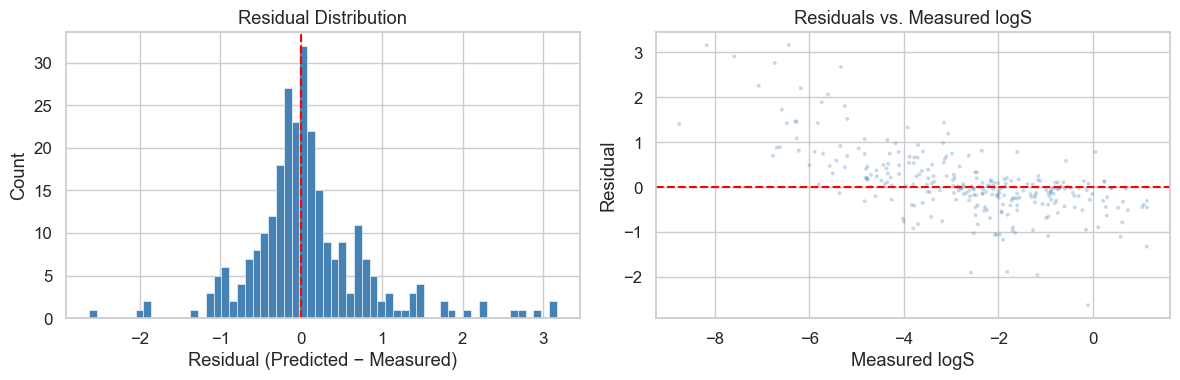

In [9]:
residuals = y_pred - y_true

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Residual histogram
axes[0].hist(residuals, bins=60, color="steelblue", edgecolor="white", linewidth=0.4)
axes[0].axvline(0, color="red", linestyle="--")
axes[0].set_xlabel("Residual (Predicted − Measured)")
axes[0].set_ylabel("Count")
axes[0].set_title("Residual Distribution")

# Residuals vs measured
axes[1].scatter(y_true, residuals, alpha=0.3, s=8, edgecolors="none", color="steelblue")
axes[1].axhline(0, color="red", linestyle="--")
axes[1].set_xlabel("Measured logS")
axes[1].set_ylabel("Residual")
axes[1].set_title("Residuals vs. Measured logS")

plt.tight_layout()
plt.show()

## 7. Solubility category breakdown

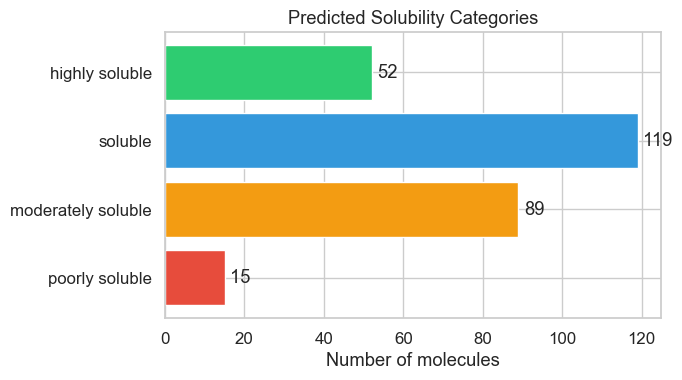

category
highly soluble         52
soluble               119
moderately soluble     89
poorly soluble         15
Name: count, dtype: int64


In [10]:
category_counts = valid_df["category"].value_counts()

fig, ax = plt.subplots(figsize=(7, 4))
order = ["highly soluble", "soluble", "moderately soluble", "poorly soluble"]
counts = [category_counts.get(c, 0) for c in order]
colors = ["#2ecc71", "#3498db", "#f39c12", "#e74c3c"]

bars = ax.barh(order, counts, color=colors)
ax.bar_label(bars, padding=4)
ax.set_xlabel("Number of molecules")
ax.set_title("Predicted Solubility Categories")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print(category_counts.reindex(order))

## 8. Inspect worst predictions

In [12]:
valid_df["abs_error"] = (valid_df["logS_predicted"] - valid_df["logS_measured"]).abs()

worst = valid_df.nlargest(10, "abs_error")[["smiles", "logS_measured", "logS_predicted", "abs_error"]]
worst

,smiles,logS_measured,logS_predicted,abs_error
49,CCC1=C(C)CN(C(=O)NCCc2ccc(cc2)S(=O)(=O)NC(=O)N...,-6.440,-3.274,3.166
68,CCCCc1oc2ccccc2c1C(=O)c1cc(I)c(OCCN(CC)CC)c(I)c1,-8.174,-5.014,3.160
179,C[C@@H]1C[C@H]2[C@@H]3CCC4=CC(=O)C=C[C@]4(C)C3...,-7.590,-4.682,2.908
93,CCOC(=O)c1cncn1[C@H](C)c1ccccc1,-6.735,-3.970,2.765
248,OCCN(CCO)c1nc(N2CCCCC2)c2nc(nc(N3CCCCC3)c2n1)N...,-5.332,-2.655,2.677
211,Clc1cccc(Cl)c1NC1=NCCN1,-0.100,-2.728,2.628
117,CN(C)C(=O)C(CCN1CCC(O)(CC1)c1ccc(Cl)cc1)(c1ccc...,-7.074,-4.816,2.258
113,CCc1ccc(CCOc2ccc(C[C@H]3SC(=O)NC3=O)cc2)nc1,-6.185,-3.981,2.204
127,CN1C(C(=O)Nc2cc(C)on2)=C(O)c2ccccc2S1(=O)=O,-5.610,-3.545,2.065
81,CCC[S@](=O)CCCN(CC)C[C@@H](O)COc1ccc(cc1)C#N,-1.170,-3.126,1.956


## 9. Predict a custom molecule

In [13]:
# Replace with any SMILES of interest
custom_smiles = "CC(=O)Nc1ccc(O)cc1"  # Paracetamol (acetaminophen)

result = predict(custom_smiles, model=model)
print(f"SMILES     : {result['smiles']}")
print(f"logS       : {result['logS']}")
print(f"Solubility : {result['solubility_mol_L']} mol/L")
print(f"Category   : {result['category']}")

SMILES     : CC(=O)Nc1ccc(O)cc1
logS       : -1.217
Solubility : 6.06e-02 mol/L
Category   : soluble
